In [ ]:
import cv2
import os

def register_user():
    # Ask for user details
    user_name = input("Enter your name: ")
    
    # Create a folder for the user
    user_folder = f"fingerprint_dataset/{user_name}"
    os.makedirs(user_folder, exist_ok=True)
    
    # Open the camera to capture fingerprint
    cap = cv2.VideoCapture(0)
    print("Press 's' to save the fingerprint image or 'q' to quit")
    
    count = 1
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to capture image.")
            break
        
        # Show the live feed
        cv2.imshow("Fingerprint Capture", frame)
        
        # Wait for user input
        key = cv2.waitKey(1) & 0xFF
        if key == ord('s'):  # Save the image
            file_path = f"{user_folder}/fingerprint_{count}.jpg"
            cv2.imwrite(file_path, frame)
            print(f"Fingerprint image saved as {file_path}")
            count += 1
        elif key == ord('q'):  # Quit
            print("Exiting fingerprint registration.")
            break

    cap.release()
    cv2.destroyAllWindows()
    
# Register a user
register_user()


Press 's' to save the fingerprint image or 'q' to quit
Fingerprint image saved as fingerprint_dataset/kamli2lijsla/fingerprint_1.jpg


In [5]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def preprocess_fingerprint(image_path):
    # Preprocess image (grayscale + resize + CLAHE)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (300, 300))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(image)
    return image, enhanced_image  # Return both original and preprocessed images

def extract_features(image):
    # Example features: sharpness and contrast
    sharpness = cv2.Laplacian(image, cv2.CV_64F).var()
    contrast = np.std(image)
    return [sharpness, contrast]

def load_dataset(dataset_path):
    features = []
    labels = []
    for user_folder in os.listdir(dataset_path):
        user_path = os.path.join(dataset_path, user_folder)
        if os.path.isdir(user_path):
            for file in os.listdir(user_path):
                image_path = os.path.join(user_path, file)
                
                # Load and preprocess image
                original_image, processed_image = preprocess_fingerprint(image_path)
                
                # Display the original image
                plt.figure(figsize=(8, 4))  # Create a wider figure to compare side-by-side
                plt.subplot(1, 2, 1)
                plt.imshow(original_image)
                plt.title("Original Fingerprint")
                plt.axis('off')

                # Display the preprocessed image
                plt.subplot(1, 2, 2)
                plt.imshow(processed_image, cmap='gray')
                plt.title("Preprocessed Fingerprint")
                plt.axis('off')

                # Show both images
                plt.show()
                
                # Extract features
                feature = extract_features(processed_image)
                features.append(feature)
                labels.append(user_folder)
                break  # Break after one image to avoid flooding
            break  # Break after processing one user folder for demo
    return np.array(features), np.array(labels)

# Load dataset
dataset_path = "fingerprint_dataset"
X, y = load_dataset(dataset_path)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Check the model's accuracy
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))


Training Accuracy: 1.0
Testing Accuracy: 1.0


In [6]:
def predict_user(image_path, model):
    # Preprocess and extract features
    processed_image = preprocess_fingerprint(image_path)
    features = extract_features(processed_image)
    
    # Predict the user
    user = model.predict([features])[0]
    return user

# Predict with a new fingerprint image
test_image_path = "mu.jpg"  # Path to the new fingerprint
predicted_user = predict_user(test_image_path, model)
print("Predicted User:", predicted_user)

Predicted User: hari


In [ ]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Set image dimensions for VGG19
IMG_SIZE = 224

def load_images_and_labels(dataset_path):
    images = []
    labels = []
    label_map = {}  # Map user folders to numeric labels
    label_index = 0

    for user_folder in os.listdir(dataset_path):
        user_path = os.path.join(dataset_path, user_folder)
        if os.path.isdir(user_path):
            # Assign a numeric label to each user
            if user_folder not in label_map:
                label_map[user_folder] = label_index
                label_index += 1

            for file in os.listdir(user_path):
                file_path = os.path.join(user_path, file)
                # Read, resize, and preprocess the image
                image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))      # Resize to 224x224
                image = np.stack((image,)*3, axis=-1)                # Convert to 3-channel (RGB)
                images.append(image)
                labels.append(label_map[user_folder])

    images = np.array(images) / 255.0  # Normalize pixel values
    labels = np.array(labels)
    return images, labels, label_map

# Load the dataset
dataset_path = "fingerprint_dataset"
images, labels, label_map = load_images_and_labels(dataset_path)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
y_train = to_categorical(y_train, num_classes=len(label_map))
y_test = to_categorical(y_test, num_classes=len(label_map))


In [4]:
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Function to build the ResNet101 model
def build_resnet101_model(num_classes):
    # Load the ResNet101 model without the top layer
    base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Freeze the base model layers
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom layers for fingerprint classification
    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

# Build the ResNet101 model
num_classes = len(label_map)
model = build_resnet101_model(num_classes)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
checkpoint = ModelCheckpoint(
    "resnet101_fingerprint_model.h5", 
    save_best_only=True, 
    monitor='val_loss', 
    mode='min'
)
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)




In [5]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=16,
    callbacks=[checkpoint, early_stopping]
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Epoch 1/10
2/2 [==============================] - 16s 9s/step - loss: 1.6918 - accuracy: 0.3333 - val_loss: 0.4204 - val_accuracy: 0.8333
Epoch 2/10
2/2 [==============================] - 3s 1s/step - loss: 0.8199 - accuracy: 0.6250 - val_loss: 0.5725 - val_accuracy: 1.0000
Epoch 3/10
2/2 [==============================] - 3s 1s/step - loss: 1.4216 - accuracy: 0.5833 - val_loss: 1.4218 - val_accuracy: 0.1667
Epoch 4/10
2/2 [==============================] - 3s 2s/step - loss: 2.0458 - accuracy: 0.3333 - val_loss: 1.1698 - val_accuracy: 0.1667
Epoch 5/10
2/2 [==============================] - 3s 1s/step - loss: 1.3326 - accuracy: 0.4583 - val_loss: 0.5175 - val_accuracy: 1.0000
Epoch 6/10
2/2 [==============================] - 8s 7s/step - loss: 1.7902 - accuracy: 0.4583 - val_loss: 0.2800 - val_accuracy: 1.0000
Epoch 7/10
2/2 [==============================] - 8s 7s/step - loss: 0.8523 - accuracy: 0.7083 - val_loss: 0.2306 - val_accuracy: 0.8333
Epoch 8/10
2/2 [========================

In [6]:

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Precision, Recall, F1-Score
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_map.keys()))


1/1 [==============================] - 2s 2s/step

Classification Report:
              precision    recall  f1-score   support

        hari       0.00      0.00      0.00         2
      ganesh       0.75      1.00      0.86         6

    accuracy                           0.75         8
   macro avg       0.38      0.50      0.43         8
weighted avg       0.56      0.75      0.64         8



c:\Users\Home\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Home\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Home\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

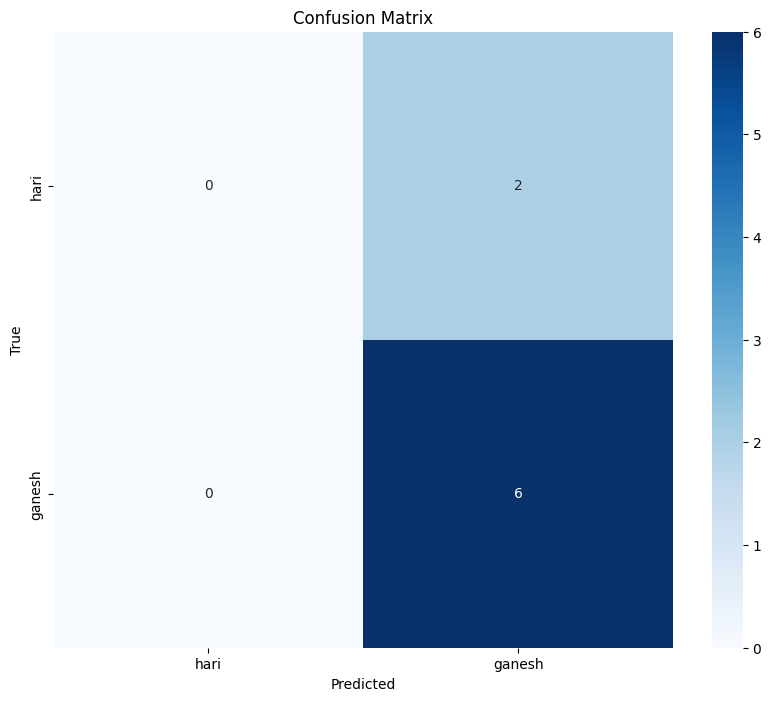

1/1 [==============================] - 0s 164ms/step
Predicted User: ganesh


In [7]:

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Predict a new fingerprint
def predict_user(image_path, model, label_map):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = np.stack((image,)*3, axis=-1)  # Convert to 3 channels
    image = image / 255.0
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)
    predicted_label = np.argmax(prediction)
    user_name = {v: k for k, v in label_map.items()}[predicted_label]
    return user_name

# Test prediction
test_image_path = "tow.jpg"  # Path to a new fingerprint image
predicted_user = predict_user(test_image_path, model, label_map)
print(f"Predicted User: {predicted_user}")